# Практическое задание №4: предсказание рейтинга настольных игр

В этом ноутбуке решается задача регрессии из соревнования **Games Rating** (Kaggle): нужно предсказать `Rating Average` по характеристикам настольной игры.

План:
1. Загрузка и первичный анализ данных.
2. Предобработка признаков (числовые + текстовые поля).
3. Сравнение нескольких моделей по метрике RMSE.
4. Обучение лучшей модели на всех данных.
5. Формирование файла `submission.csv`.

In [1]:
# Если библиотек нет, раскомментируй строку ниже и запусти один раз
# !pip install -q pandas numpy scikit-learn matplotlib seaborn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge, SGDRegressor
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')

print('Train shape:', train.shape)
print('Test shape :', test.shape)
print('Train columns:')
print(train.columns.tolist())

Train shape: (15257, 14)
Test shape : (5086, 13)
Train columns:
['ID', 'Name', 'Year Published', 'Min Players', 'Max Players', 'Play Time', 'Min Age', 'Users Rated', 'Rating Average', 'BGG Rank', 'Complexity Average', 'Owned Users', 'Mechanics', 'Domains']


In [3]:
train.head(3)

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains
0,174430.0,Gloomhaven,2017.0,1,4,120,14,42055,"8,79",1,"3,86",68323.0,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games"
1,224517.0,Brass: Birmingham,2018.0,2,4,120,14,19217,"8,66",3,"3,91",28785.0,"Hand Management, Income, Loans, Market, Networ...",Strategy Games
2,167791.0,Terraforming Mars,2016.0,1,5,120,12,64864,"8,43",4,"3,24",87099.0,"Card Drafting, Drafting, End Game Bonuses, Han...",Strategy Games


In [4]:
print('Пропуски в train:')
(train.isna().sum().sort_values(ascending=False).head(10))

Пропуски в train:


Domains           7649
Mechanics         1200
Owned Users         17
ID                  10
Year Published       1
Name                 0
Min Players          0
Max Players          0
Play Time            0
Min Age              0
dtype: int64

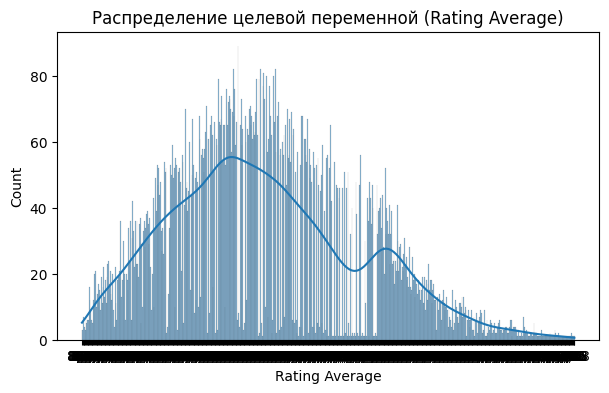

count     15257
unique      610
top        6,50
freq         89
Name: Rating Average, dtype: object


In [5]:
plt.figure(figsize=(7, 4))
sns.histplot(train['Rating Average'], bins=40, kde=True)
plt.title('Распределение целевой переменной (Rating Average)')
plt.xlabel('Rating Average')
plt.ylabel('Count')
plt.show()

print(train['Rating Average'].describe())

## Подготовка признаков

Используем два типа признаков:
- **Числовые**: год публикации, количество игроков, длительность партии, возраст, популярность и т.д.
- **Текстовые**: `Name`, `Mechanics`, `Domains`.

Для текста используем TF-IDF, для числовых признаков - заполнение пропусков медианой и масштабирование.

In [6]:
TARGET = 'Rating Average'
ID_COL = 'ID'

numeric_features = [
    'Year Published', 'Min Players', 'Max Players', 'Play Time',
    'Min Age', 'Users Rated', 'BGG Rank', 'Complexity Average', 'Owned Users'
]

text_features = ['Name', 'Mechanics', 'Domains']

# В датасете часть числовых значений хранится строками с запятой (например, 3,91),
# поэтому приводим такие колонки к float заранее.
for col in numeric_features + [TARGET]:
    train[col] = pd.to_numeric(
        train[col].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

for col in numeric_features:
    test[col] = pd.to_numeric(
        test[col].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

X = train[numeric_features + text_features].copy()
y = train[TARGET].copy()
X_test = test[numeric_features + text_features].copy()

# Явно приводим текст к строке, чтобы векторизаторы не падали на NaN
for col in text_features:
    X[col] = X[col].fillna('')
    X_test[col] = X_test[col].fillna('')

In [7]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('name_tfidf', TfidfVectorizer(max_features=1500, ngram_range=(1, 2), min_df=2), 'Name'),
        ('mechanics_tfidf', TfidfVectorizer(max_features=1200, token_pattern=r'[^,]+'), 'Mechanics'),
        ('domains_tfidf', TfidfVectorizer(max_features=100, token_pattern=r'[^,]+'), 'Domains'),
    ],
    remainder='drop'
)

rmse_scorer = make_scorer(
    lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
    greater_is_better=False
)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## Сравнение моделей

Сравним 3 модели:
1. `Ridge` на всех признаках (числа + TF-IDF текст).
2. `SGDRegressor` на всех признаках.
3. `RandomForestRegressor` только на числовых признаках (как нелинейный бенчмарк).

In [ ]:
models = {
    'Ridge (num + text)': Pipeline([
        ('prep', preprocessor),
        ('model', Ridge(alpha=1.0))
    ]),
    'SGDRegressor (num + text)': Pipeline([
        ('prep', preprocessor),
        ('model', SGDRegressor(
            loss='squared_error',
            penalty='l2',
            alpha=1e-4,
            max_iter=3000,
            random_state=RANDOM_STATE
        ))
    ]),
    'RandomForest (num only)': Pipeline([
        ('prep', ColumnTransformer([
            ('num', numeric_transformer, numeric_features)
        ])),
        ('model', RandomForestRegressor(
            n_estimators=350,
            max_depth=None,
            min_samples_leaf=1,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}

scores = {}
for name, model in models.items():
    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring=rmse_scorer,
        n_jobs=1
    )
    rmse_values = -cv_scores
    scores[name] = (rmse_values.mean(), rmse_values.std())
    print(f'{name:30s} -> RMSE: {rmse_values.mean():.5f} ± {rmse_values.std():.5f}')

best_model_name = min(scores, key=lambda k: scores[k][0])
print('Лучшая модель по CV:', best_model_name)

Ridge (num + text)             -> RMSE: 0.55431 ± 0.00929
SGDRegressor (num + text)      -> RMSE: 0.86964 ± 0.02753


In [ ]:
results_df = pd.DataFrame([
    {
        'model': name,
        'cv_rmse_mean': vals[0],
        'cv_rmse_std': vals[1]
    }
    for name, vals in scores.items()
]).sort_values('cv_rmse_mean')

results_df

,model,cv_rmse_mean,cv_rmse_std
2,RandomForest (num only),0.240476,0.011893
0,Ridge (num + text),0.554306,0.009288
1,SGDRegressor (num + text),0.869638,0.027530


## Обучение лучшей модели и предсказание на test

In [ ]:
best_model = models[best_model_name]
best_model.fit(X, y)

test_preds = best_model.predict(X_test)

# На всякий случай ограничим рейтинг в разумном диапазоне
# (в BGG рейтинг обычно лежит примерно в интервале 1..10)
test_preds = np.clip(test_preds, 1, 10)

# В соревновании нужен технический индекс строки test: 0..N-1
submission = pd.DataFrame({
    'index': np.arange(len(test), dtype=int),
    'Rating Average': test_preds
})

submission.head()

,index,Rating Average
0,161936.0,8.045429
1,12333.0,7.964886
2,115746.0,8.115429
3,169786.0,8.276686
4,28720.0,8.048000


In [ ]:
submission.to_csv('submission.csv', index=False)
print('Файл сохранен: submission.csv')
print('Количество строк:', len(submission))

Файл сохранен: submission.csv
Количество строк: 5086


## Короткий вывод

- Проведен анализ и подготовка данных.
- Сравнены несколько моделей по RMSE на кросс-валидации.
- Обучена лучшая модель и получены предсказания для теста.
- Сформирован файл `submission.csv`, который можно отправлять в Kaggle.